# Building with LangGraph

In [47]:
# Install all required packages
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Building a ChatBot

In [21]:
from langgraph.graph import StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

In [22]:
# loading the API key from .env
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=True)

True

In [23]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)

# defining the chatbot node
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# adding the node to the graph
graph_builder.add_node("chatbot", chatbot)

# setting the entry and the finish points
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

graph = graph_builder.compile()

## Visualizing the Graph

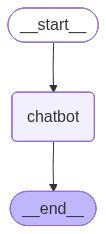

In [24]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
pip install -q grandalf

Note: you may need to restart the kernel to use updated packages.


In [26]:
print(graph.get_graph().draw_ascii())

+-----------+  
| __start__ |  
+-----------+  
      *        
      *        
      *        
 +---------+   
 | chatbot |   
 +---------+   
      *        
      *        
      *        
 +---------+   
 | __end__ |   
 +---------+   


## Running the ChatBot

In [ ]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye',  'q']:
        print('Goodbye!')
        break

    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print(f'Assistant: {value["messages"][-1].content}')
            print('-' * 20)

User:  Paris is ...


Assistant: Paris is the capital city of France and is known for its rich history, art, culture, and architecture. Often referred to as "The City of Light," Paris is famous for iconic landmarks such as the Eiffel Tower, the Louvre Museum, Notre-Dame Cathedral, and the Champs-Élysées. The city is also renowned for its culinary scene, fashion, and vibrant neighborhoods like Montmartre and Le Marais. Paris has a significant influence on art, philosophy, and politics and continues to be a major center for tourism and culture worldwide.
--------------------


User:  History of Notre-Dame.


Assistant: Notre-Dame de Paris, one of the most iconic Gothic cathedrals in the world, has a rich history that dates back to the 12th century. Here’s a brief overview of its history:

### Early Construction (1163-1345)
- **Foundation**: The construction of Notre-Dame began in 1163 under Bishop Maurice de Sully. The site was chosen for its central location in Paris, on Île de la Cité.
- **Architectural Style**: The cathedral is a prime example of French Gothic architecture, characterized by its ribbed vaults, flying buttresses, and large stained glass windows.
- **Completion**: The main structure was largely completed by 1345, although the cathedral continued to be modified and expanded over the centuries.

### Medieval Period (14th-16th Century)
- **Significant Events**: Notre-Dame witnessed numerous significant events, including royal ceremonies, such as the coronation of Henry VI of England in 1431 and the beatification of Joan of Arc in 1909.
- **Art and Culture**: The cathedral bec

User:  top 5 places to visit


Assistant: Here are five incredible places to visit, each offering unique experiences and attractions:

1. **Kyoto, Japan**: Known for its stunning temples, traditional wooden houses, and beautiful gardens, Kyoto is a city that showcases Japan's rich cultural heritage. Don't miss the iconic Kinkaku-ji (Golden Pavilion) and the historic Gion district, famous for its geisha culture.

2. **Santorini, Greece**: Famous for its breathtaking sunsets, white-washed buildings, and crystal-clear waters, Santorini is a picturesque island in the Aegean Sea. Explore the charming villages of Oia and Fira, relax on the unique volcanic beaches, and indulge in delicious Greek cuisine.

3. **Machu Picchu, Peru**: This ancient Incan city set high in the Andes Mountains is a must-visit for history and adventure enthusiasts. Trek the Inca Trail or take a train to reach this UNESCO World Heritage site, where you can explore the impressive ruins and enjoy stunning mountain views.

4. **Rome, Italy**: A city s

## Tavily AI

In [9]:
# pip install -q tavily-python

Note: you may need to restart the kernel to use updated packages.


In [10]:
# from dotenv import load_dotenv, find_dotenv
# load_dotenv(find_dotenv(), override=True)

True

In [27]:
from tavily import TavilyClient
import os

# initializing a Tavily client
client = TavilyClient(api_key=os.environ.get('TAVILY_API_KEY'))

response = client.search(query='EUFA EURO 2024 FINAL')
response

{'query': 'EUFA EURO 2024 FINAL',
 'response_time': 1.13,
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.uefa.com/uefaeuro/history/seasons/2024/',
   'title': 'Season 2024 | UEFA EURO 2024',
   'content': 'Official in-depth guide to UEFA EURO 2024, including results, stats and video highlights ... 2024 final: Spain 2-1 England. Live 17/07/2024. 2024 final: Spain 2-1',
   'score': 0.9984269,
   'raw_content': None},
  {'url': 'https://en.wikipedia.org/wiki/UEFA_Euro_2024_final',
   'title': 'UEFA Euro 2024 final - Wikipedia',
   'content': 'Spain won this time with Randal Kolo Muani opening the scoring for the French with a header in the 9th minute, but Yamal then equalised for the Spanish in the 21st minute with a shot to the left corner from outside the penalty area, Olmo then scored the winner for Spain in the 25th minute – this was originally given as a Jules Koundé own goal but after a review was given to Olmo – this sent Spain throu

In [28]:
for result in response['results']:
    print(f"Title: {result['title']}, URL: {result['url']}")

Title: Season 2024 | UEFA EURO 2024, URL: https://www.uefa.com/uefaeuro/history/seasons/2024/
Title: UEFA Euro 2024 final - Wikipedia, URL: https://en.wikipedia.org/wiki/UEFA_Euro_2024_final
Title: UEFA eEURO 2024 Finals - YouTube, URL: https://www.youtube.com/watch?v=3puJpi5yLcY
Title: Euro 2024 final: Spain defeat England reaction, analysis - ESPN, URL: https://www.espn.com/soccer/story/_/id/40560458/euro-2024-final-england-spain-reaction-analysis-highlights
Title: Euro 2024 final heartbreak for England as late Spain goal ... - BBC, URL: https://www.bbc.com/sport/football/live/cp68zzx8x4rt


In [29]:
response = client.search(
    query='What are LLM agents?',
    search_depth='advanced',
    max_results=7,
    include_images=True,
    include_answer=True,
    include_raw_content=False
)
response

{'query': 'What are LLM agents?',
 'response_time': 2.53,
 'follow_up_questions': None,
 'answer': 'LLM agents are AI systems using large language models to understand and generate human language, perform tasks, and interact autonomously. They combine memory, planning, and tool use for complex problem-solving. They enhance decision-making and user interactions.',
 'images': ['https://substackcdn.com/image/fetch/$s_!A_Oy!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fc3177e12-432e-4e41-814f-6febf7a35f68_1360x972.png',
  'https://daxg39y63pxwu.cloudfront.net/images/blog/llm-agents/LLM_Agents_Introduction_to_Implementation.webp',
  'https://promptengineering.org/content/images/2023/08/Prompt-engineering---Large-Language-Model-LLM--Autonomous-Agent-Structure---PromptEngineering.org.jpg',
  'https://lilianweng.github.io/posts/2023-06-23-agent/agent-overview.png',
  'https://cdn.prod.website-files.com/614c82ed388d53640613982e/6

In [30]:
answer = client.qna_search(query='Who won the UEFA Champions League in 2024?')
print(answer)

Real Madrid won the 2023–24 UEFA Champions League. Paris Saint-Germain won the 2024–25 UEFA Champions League.


/tmp/ipykernel_574650/92903426.py:1: DeprecationWarning: qna_search is deprecated and will be removed in future versions.
  answer = client.qna_search(query='Who won the UEFA Champions League in 2024?')


In [31]:
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

query = 'What is the "Reflection & Critique" pattern used in agentic applications and LangGraph?'

response = client.search(query, max_results=5, search_depth='advanced')['results']
response

[{'url': 'https://medium.com/aimonks/reflection-agents-with-langgraph-agentic-llm-based-applications-87e43c27adc7',
  'title': 'Reflection Agents With LangGraph | Agentic LLM Based Applications',
  'content': '## What Is Reflection?\n\nReflection is a prompting strategy used to improve the quality and success rate of agents and similar AI systems. It involves prompting an LLM to reflect on and critique its past actions, sometimes incorporating additional external information such as tools and observations.\n\nImagine an LLM based application like ChatGPT. If you ask it to write you code. It immediately begins to spit out content of the code. Do you know any programmer that just writes code that fast and never tests it, but pushes it into production? Forget about other programmers, just maybe they are that intelligent. Can you personally do that? Of course not, highly unlikely. [...] Code With Prince\n\nThe generator will do the generative part of an LLM, generating answers to user quer

In [32]:
# setting up the OpenAI API prompt
prompt = [
    {
        'role': 'system',
        'content': f'''You are an AI critical thinker research assistant. 
        Your sole purpose is to write well written, objective and structured reports on given text.'''
    },
    {
        'role': 'user',
        'content': f'''Information: """{response}"""
        Using the above information, answer the following query: """{query}""" in a detailed report'''
    }
]

# convert_openai_messages was removed from langchain.adapters; build LangChain messages directly
role_map = {'system': SystemMessage, 'user': HumanMessage}
lc_messages = [role_map[m['role']](content=m['content']) for m in prompt]
lc_messages

[SystemMessage(content='You are an AI critical thinker research assistant. \n        Your sole purpose is to write well written, objective and structured reports on given text.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Information: """[{\'url\': \'https://medium.com/aimonks/reflection-agents-with-langgraph-agentic-llm-based-applications-87e43c27adc7\', \'title\': \'Reflection Agents With LangGraph | Agentic LLM Based Applications\', \'content\': \'## What Is Reflection?\\n\\nReflection is a prompting strategy used to improve the quality and success rate of agents and similar AI systems. It involves prompting an LLM to reflect on and critique its past actions, sometimes incorporating additional external information such as tools and observations.\\n\\nImagine an LLM based application like ChatGPT. If you ask it to write you code. It immediately begins to spit out content of the code. Do you know any programmer that just writes code that fast and never tests i

In [19]:
response = ChatOpenAI(model='gpt-5.1').invoke(lc_messages)
print(response.content)

Below is a structured report on the **“Reflection & Critique” pattern** as used in **agentic AI applications** and, in particular, in **LangGraph-based systems**.

---

## 1. Concept Overview

The **Reflection & Critique pattern** (often shortened to *Reflection pattern*) is an **agentic AI design pattern** in which an AI system:

1. **Generates** an initial output (answer, code, plan, etc.).
2. **Reflects on / critiques** that output—often as if it were a separate “critic” agent.
3. **Refines** the output iteratively based on its own critique.

Instead of treating generation as a one-shot process, the system explicitly builds in **feedback and revision loops**, closely mimicking how humans draft, review, and edit their work.

This pattern:

- Is especially effective for **LLMs (large language models)**.
- Aims to enhance **accuracy, clarity, and reliability**.
- Is central to many **agentic workflows**, and is natively supported in frameworks like **LangGraph**.

---

## 2. Core Mecha

## Enhancing the Chatbot with Tools

In [34]:
# from dotenv import load_dotenv, find_dotenv
# load_dotenv(find_dotenv(), override=True)

True

In [35]:
# defining the tools
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=3)
tools = [tool]

/tmp/ipykernel_574650/3584848301.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=3)


In [36]:
response = tool.invoke('What is GPT 5.4?')
response

[{'title': 'Introducing GPT-5.4 - OpenAI',
  'url': 'https://openai.com/index/introducing-gpt-5-4/',
  'content': "In Codex and the API, GPT‑5.4 is the first general-purpose model we’ve released with native, state-of-the-art computer-use capabilities, enabling agents to operate computers and carry out complex workflows across applications. It supports up to 1M tokens of context, allowing agents to plan, execute, and verify tasks across long horizons. GPT‑5.4 also improves how models work across large ecosystems of tools and connectors with tool search, helping agents find and use the right tools more efficiently without sacrificing intelligence. Finally, GPT‑5.4 is ourmost token efficient reasoning modelyet, using significantly fewer tokens to solve problems when compared to GPT‑5.2—translating to reduced token usage and faster speeds. [...] GPT‑5.4 is our first mainline reasoning model that incorporates the frontier coding capabilities of GPT‑5.3‑codex and that is rolling out across C

In [37]:
from langgraph.graph import StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

# --- new import
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)

# tell the LLM which tools it can call
llm_with_tools = llm.bind_tools(tools)

# change the chatbot() node function. Use llm_with_tools instead of llm.
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

# --- add this:
# run the tools if they are called by adding the tools to a new node.
# This node runs the tools requested in the last AIMessage.
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)
# ---

# --- add this
# define the conditional_edges.
# we'll use the prebuilt tools_condition in the conditional_edge to route to the ToolNode if the last message has tool calls,
# otherwise, route to the end.
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
# ---

# any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")

graph_builder.set_entry_point("chatbot")

# we don't need to explicitly set a finish_point because our graph already has a way to finish!
# graph_builder.set_finish_point("chatbot")

graph = graph_builder.compile()

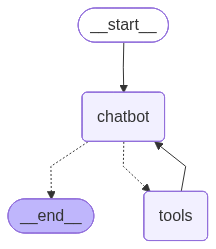

In [38]:
# Let's visualize the graph we've built. We'll use the same code as in the previous video.
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


In [39]:
while True:
    user_input = input('User: ')
    if user_input.lower() in ['quit', 'exit', 'bye',  'q']:
        print('Goodbye!')
        break
        
    for event in graph.stream({'messages': ('user', user_input)}):
        for value in event.values():
            print('Assistant: ', value['messages'][-1].content)
        print('-' * 50)



User:  Claude Code vs. OpenAI Codex


Assistant:  
--------------------------------------------------
Assistant:  [{"title": "Codex app features - OpenAI for developers", "url": "https://developers.openai.com/codex/app/features/", "content": "## Image input\n\nYou can drag and drop images into the prompt composer to include them as context. Hold down `Shift` while dropping an image to add the image to the context.\n\nYou can also ask Codex to view images on your system. By giving Codex tools to take screenshots of the app you are working on, Codex can verify the work it’s doing.\n\n## Notifications\n\nBy default, the Codex app sends notifications when a task completes or needs approval while the app is in the background.\n\nIn the Codex app settings, you can choose to never send notifications or always send them, even when the app is in focus.\n\n## Keep your computer awake [...] ### Realtime API\n\n Overview\n Connect \n  + WebRTC\n  + WebSocket\n  + SIP\n Usage \n  + Using realtime models\n  + Managing conversations\n  +

User:  quit


Goodbye!


##  Adding Memory to the Chatbot

In [40]:
# pip install -q langgraph-checkpoint-sqlite

In [29]:
# loading the API key form .env
# from dotenv import load_dotenv, find_dotenv
# load_dotenv(find_dotenv(), override=True)

True

In [43]:
from langgraph.graph import StateGraph
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools.tavily_search import TavilySearchResults

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tool = TavilySearchResults(max_results=3)
tools = [tool]

llm = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.5)
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}

graph_builder.add_node('chatbot', chatbot)
tool_node = ToolNode(tools=[tool])
graph_builder.add_node('tools', tool_node)

graph_builder.add_conditional_edges(
    'chatbot',
    tools_condition,
)

graph_builder.add_edge('tools', 'chatbot')
graph_builder.set_entry_point('chatbot')

In [48]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import MemorySaver ### fix

memory = SqliteSaver.from_conn_string(':memory:')
graph = graph_builder.compile(checkpointer=MemorySaver()) ### fix


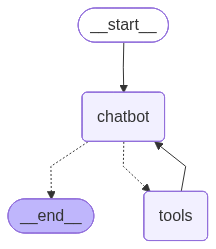

In [49]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [50]:
config = {'configurable': {'thread_id': '1'}}

In [51]:
prompt = 'What is the lastest AI model developed by OpenAI?'

# streaming the events. 
events = graph.stream(
    {'messages': [('user', prompt)]}, config, stream_mode='values'
)

for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

What is the lastest AI model developed by OpenAI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_wMnrAHl1QLbYUZL6RFRARSkr)
 Call ID: call_wMnrAHl1QLbYUZL6RFRARSkr
  Args:
    query: latest AI model developed by OpenAI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "OpenAI models: All the models and what they're best for", "url": "https://zapier.com/blog/openai-models/", "content": "Hero image with the OpenAI logo\n\nKeeping track of all the new AI models getting released at the moment is practically a full-time job. The most recent model, GPT-5.4, was released literally days after GPT-5.3 (and was barely a release to begin with).\n\nI've been writing about OpenAI's models for the past few years, and it feels like every time I publish an article, an

In [52]:
# It has memory!
prompt = 'What about Google?'
events = graph.stream(
    {'messages': [('user', prompt)]}, config, stream_mode='values'
)
for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

What about Google?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_aW6e8IvoMOP8eIPdYNABUnla)
 Call ID: call_aW6e8IvoMOP8eIPdYNABUnla
  Args:
    query: latest AI model developed by Google
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Google's year in review: 8 areas with research breakthroughs in 2025", "url": "https://blog.google/innovation-and-ai/products/2025-research-breakthroughs/", "content": "In 2025, Google made significant AI research breakthroughs with models like Gemini 3 and Gemma 3. These advancements improved AI's reasoning, multimodality, and efficiency, leading to new products and features across Google's portfolio. Expect more AI-driven innovations in science, computing, and tools for global challenges as Google prioritizes respon

In [53]:
prompt = 'What did I ask you so far?'

events = graph.stream(
    {'messages': [('user', prompt)]}, config, stream_mode='values'
)
for event in events:
    event['messages'][-1].pretty_print()


================================ Human Message =================================

What did I ask you so far?
================================== Ai Message ==================================

So far, you have asked about:

1. The latest AI model developed by OpenAI.
2. The latest AI model developed by Google.


In [54]:
# NEW THREAD => no memory
config1 = {"configurable": {"thread_id": "10"}}

prompt = 'What did I ask you so far?'

events = graph.stream(
    {"messages": [("user", prompt)]}, config1, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

What did I ask you so far?
================================== Ai Message ==================================

You haven't asked me anything yet in this conversation. How can I assist you today?


In [55]:
snapshot = graph.get_state(config)
snapshot


StateSnapshot(values={'messages': [HumanMessage(content='What is the lastest AI model developed by OpenAI?', additional_kwargs={}, response_metadata={}, id='37050803-7d8e-417a-ad67-a1d94390d7f4'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 91, 'total_tokens': 115, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_d4723c3c8f', 'id': 'chatcmpl-DIxiTbvaNGv8izmUYGAc3P8FCohAQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ce794-f740-7870-9ad0-74fcc0dbd27c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest AI model developed by OpenAI'}, 'id': 'call_wMnrAHl1QLbYUZL6RFRARSkr', 'ty

In [56]:
snapshot.next

()